# Face Recognition Benchmark: Howdy (dlib) vs GhostFaceNet

Compares the facial recognition pipeline used by Howdy (dlib ResNet-based) against
GhostFaceNet ([HamadYA/GhostFaceNets](https://github.com/HamadYA/GhostFaceNets))
on the LFW (Labeled Faces in the Wild) verification benchmark.

**Metrics evaluated:** accuracy, false positive rate (FAR), false negative rate (FRR),
confusion matrix values, and ROC / AUC.

In [32]:
%pip install -q tensorflow scikit-learn matplotlib tqdm pandas dlib opencv-python face-recognition

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import numpy as np
import cv2
import dlib
import face_recognition_models
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

print(f"TensorFlow {tf.__version__}")
print(f"dlib      {dlib.__version__}")
print(f"OpenCV    {cv2.__version__}")

TensorFlow 2.21.0
dlib      20.0.1
OpenCV    4.13.0


In [4]:
# Load the full LFW benchmark: 6 000 pairs
# Format: (300 same-person + 300 different-person) × 10 folds, interleaved.
from pathlib import Path as _Path
import numpy as np

_LFW_ROOT  = _Path.home() / 'scikit_learn_data' / 'lfw_home'
_LFW_IMGS  = _LFW_ROOT / 'lfw_funneled'
_PAIRS_FILE = _LFW_ROOT / 'pairs.txt'

pairs:    list[tuple[str, str, int]] = []
fold_ids: list[int]                  = []

with open(_PAIRS_FILE) as _f:
    n_folds, n_per_fold = map(int, _f.readline().split())
    for _fold in range(n_folds):
        # 300 same-person pairs (3 columns: name, idx1, idx2)
        for _ in range(n_per_fold):
            _parts = _f.readline().split()
            _name, _n1, _n2 = _parts[0], int(_parts[1]), int(_parts[2])
            _p1 = str(_LFW_IMGS / _name / f'{_name}_{_n1:04d}.jpg')
            _p2 = str(_LFW_IMGS / _name / f'{_name}_{_n2:04d}.jpg')
            pairs.append((_p1, _p2, 1))
            fold_ids.append(_fold)
        # 300 different-person pairs (4 columns: name1, idx1, name2, idx2)
        for _ in range(n_per_fold):
            _parts = _f.readline().split()
            _name1, _n1, _name2, _n2 = _parts[0], int(_parts[1]), _parts[2], int(_parts[3])
            _p1 = str(_LFW_IMGS / _name1 / f'{_name1}_{_n1:04d}.jpg')
            _p2 = str(_LFW_IMGS / _name2 / f'{_name2}_{_n2:04d}.jpg')
            pairs.append((_p1, _p2, 0))
            fold_ids.append(_fold)

fold_ids   = np.array(fold_ids)
n_folds_lfw = n_folds
same_count  = sum(1 for *_, l in pairs if l == 1)
diff_count  = sum(1 for *_, l in pairs if l == 0)
print(f'Loaded {len(pairs)} pairs  ({n_folds} folds × {n_per_fold} same + {n_per_fold} diff)')
print(f'  Same-person (positive):      {same_count}')
print(f'  Different-person (negative): {diff_count}')
print(f'  Image directory:             {_LFW_IMGS}')


Loaded 6000 pairs  (10 folds × 300 same + 300 diff)
  Same-person (positive):      3000
  Different-person (negative): 3000
  Image directory:             /home/carlos/scikit_learn_data/lfw_home/lfw_funneled


In [5]:
# 5-point ArcFace reference landmarks for 112×112 output
ARCFACE_REF = np.float32([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041],
])


def align_face_112(image: np.ndarray, landmarks: np.ndarray) -> np.ndarray:
    """Warp face to 112×112 using a 5-point similarity transform (ArcFace protocol)."""
    transform, _ = cv2.estimateAffinePartial2D(
        landmarks.astype(np.float32), ARCFACE_REF, method=cv2.RANSAC
    )
    if transform is None:
        return cv2.resize(image, (112, 112))
    return cv2.warpAffine(image, transform, (112, 112))


def extract_arcface_landmarks_68(shape) -> np.ndarray:
    """Convert dlib 68-point shape to the 5 ArcFace keypoints.

    ArcFace order: left-eye-center, right-eye-center, nose-tip,
                   left-mouth-corner, right-mouth-corner.
    From dlib-68: eyes 36-41 / 42-47, nose 30, mouth corners 48 / 54.
    """
    pts = np.array([(shape.part(i).x, shape.part(i).y) for i in range(68)],
                   dtype=np.float32)
    return np.array([
        pts[36:42].mean(axis=0),   # left  eye centre
        pts[42:48].mean(axis=0),   # right eye centre
        pts[30],                   # nose tip
        pts[48],                   # left  mouth corner
        pts[54],                   # right mouth corner
    ], dtype=np.float32)


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = a / (np.linalg.norm(a) + 1e-10)
    b = b / (np.linalg.norm(b) + 1e-10)
    return float(np.dot(a, b))


def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def compute_metrics(scores: list[float], labels: list[int], threshold: float) -> dict:
    """TP/FP/TN/FN and derived rates at a given decision threshold."""
    preds = (np.array(scores) >= threshold).astype(int)
    lab   = np.array(labels)
    tp = int(np.sum((preds == 1) & (lab == 1)))
    fp = int(np.sum((preds == 1) & (lab == 0)))
    tn = int(np.sum((preds == 0) & (lab == 0)))
    fn = int(np.sum((preds == 0) & (lab == 1)))
    accuracy = (tp + tn) / len(lab)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return {'accuracy': accuracy, 'fpr': fpr, 'fnr': fnr,
            'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn}


def find_best_threshold(scores: list[float], labels: list[int]) -> tuple[float, float]:
    """Return (threshold, accuracy) that maximises accuracy over 400 candidates."""
    thresholds = np.linspace(np.min(scores), np.max(scores), 400)
    best_acc, best_t = 0.0, thresholds[0]
    for t in thresholds:
        acc = compute_metrics(scores, labels, t)['accuracy']
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


def lfw_10fold_accuracy(
    scores: np.ndarray,
    labels: np.ndarray,
    folds: np.ndarray,
    n_folds: int = 10,
) -> tuple[float, float]:
    """Standard LFW 10-fold cross-validated accuracy.

    For each fold: find optimal threshold on the 9 training folds,
    then measure accuracy on the held-out test fold.
    Returns (mean_accuracy, std_accuracy).
    """
    fold_accs = []
    for k in range(n_folds):
        test_mask  = folds == k
        train_mask = ~test_mask
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue
        best_t, _ = find_best_threshold(scores[train_mask].tolist(),
                                        labels[train_mask].tolist())
        acc = compute_metrics(scores[test_mask].tolist(),
                              labels[test_mask].tolist(), best_t)['accuracy']
        fold_accs.append(acc)
    return float(np.mean(fold_accs)), float(np.std(fold_accs))


In [6]:
# Howdy / dlib pipeline (unchanged — uses 5-point predictor + 128-d ResNet)
HOG_DETECTOR    = dlib.get_frontal_face_detector()
SHAPE_PRED_5    = dlib.shape_predictor(
    face_recognition_models.pose_predictor_five_point_model_location()
)
FACE_ENCODER    = dlib.face_recognition_model_v1(
    face_recognition_models.face_recognition_model_location()
)

# 68-point predictor for GhostFaceNet alignment
# Provides proper eye centres, nose tip and mouth corners.
SHAPE_PRED_68 = dlib.shape_predictor(
    face_recognition_models.pose_predictor_model_location()
)

print('Models loaded')
print('  HOG detector     : dlib frontal face detector')
print('  5-pt predictor   : shape_predictor_5_face_landmarks (Howdy pipeline)')
print('  68-pt predictor  : shape_predictor_68_face_landmarks (GhostFaceNet alignment)')
print('  dlib ResNet-128  : dlib_face_recognition_resnet_model_v1')


def get_howdy_embedding(img_path: str) -> np.ndarray | None:
    """128-d embedding using Howdy's dlib pipeline (unchanged)."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detections = HOG_DETECTOR(rgb, 1)
    if not detections:
        return None
    detection = max(detections, key=lambda d: d.width() * d.height())
    landmarks = SHAPE_PRED_5(rgb, detection)
    return np.array(FACE_ENCODER.compute_face_descriptor(rgb, landmarks, 1))


Models loaded
  HOG detector     : dlib frontal face detector
  5-pt predictor   : shape_predictor_5_face_landmarks (Howdy pipeline)
  68-pt predictor  : shape_predictor_68_face_landmarks (GhostFaceNet alignment)
  dlib ResNet-128  : dlib_face_recognition_resnet_model_v1


In [7]:
GHOSTFACENET_MODEL_PATH = Path('ghostfacenets') / 'checkpoints' / 'ghostnetv1_w1.3_s2.h5'

class _DepthwiseConv2DCompat(tf.keras.layers.DepthwiseConv2D):
    @classmethod
    def from_config(cls, config):
        config.pop('groups', None)
        return super().from_config(config)

ghostfacenet_model = tf.keras.models.load_model(
    str(GHOSTFACENET_MODEL_PATH),
    compile=False,
    custom_objects={'DepthwiseConv2D': _DepthwiseConv2DCompat},
)
print('GhostFaceNet model loaded')
print(f'  Input shape:  {ghostfacenet_model.input_shape}')
print(f'  Output shape: {ghostfacenet_model.output_shape}')

_GFN_INPUT_KEY = ghostfacenet_model.inputs[0].name.split(':')[0]


def _gfn_forward(aligned_rgb: np.ndarray) -> np.ndarray:
    """Run one 112×112 RGB image through GhostFaceNet; return raw 512-d embedding."""
    inp = (np.float32(aligned_rgb) - 127.5) * 0.0078125
    inp = tf.constant(inp[np.newaxis])
    return ghostfacenet_model({_GFN_INPUT_KEY: inp}, training=False).numpy()[0]


def get_ghostfacenet_embedding(img_path: str) -> np.ndarray | None:
    """512-d L2-normalised embedding using the GhostFaceNet paper's protocol.

    Fixes vs the previous version:
    1. Uses dlib's 68-point predictor to extract the correct 5 ArcFace keypoints
       (eye centres + nose tip + mouth corners).  The old code mapped dlib-5 eye
       corners to ArcFace mouth positions, producing a broken warp.
    2. Flip augmentation: averages the embedding of the original and horizontally
       flipped image before L2 normalisation, as done in the paper (flip=True).
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:
        detections = HOG_DETECTOR(rgb, 1)
        if not detections:
            return None
        detection = max(detections, key=lambda d: d.width() * d.height())
        shape     = SHAPE_PRED_68(rgb, detection)
        landmarks = extract_arcface_landmarks_68(shape)
        aligned   = align_face_112(rgb, landmarks)
    except Exception:
        return None

    emb   = _gfn_forward(aligned)
    emb_f = _gfn_forward(np.fliplr(aligned))   # horizontal flip
    emb_avg = emb + emb_f                        # sum (equivalent to averaging before norm)
    return emb_avg / (np.linalg.norm(emb_avg) + 1e-10)


E0000 00:00:1778840724.614170    7879 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


GhostFaceNet model loaded
  Input shape:  (None, 112, 112, 3)
  Output shape: (None, 512)


In [8]:
print(f'Extracting embeddings for {len(pairs)} pairs...')

howdy_scores:  list[float] = []
ghost_scores:  list[float] = []
eval_labels:   list[int]   = []
eval_folds:    list[int]   = []
skipped = 0

for (img1_path, img2_path, label), fold in tqdm(
    zip(pairs, fold_ids), total=len(pairs), desc='Pairs'
):
    e1_h = get_howdy_embedding(img1_path)
    e2_h = get_howdy_embedding(img2_path)
    e1_g = get_ghostfacenet_embedding(img1_path)
    e2_g = get_ghostfacenet_embedding(img2_path)

    if any(e is None for e in (e1_h, e2_h, e1_g, e2_g)):
        skipped += 1
        continue

    howdy_scores.append(-l2_distance(e1_h, e2_h))
    ghost_scores.append(cosine_similarity(e1_g, e2_g))
    eval_labels.append(label)
    eval_folds.append(int(fold))

eval_folds_arr = np.array(eval_folds)

print(f'\nProcessed: {len(eval_labels)} pairs  |  Skipped (no face): {skipped}')
print(f'  Same-person (positive):      {sum(eval_labels)}')
print(f'  Different-person (negative): {len(eval_labels) - sum(eval_labels)}')


Extracting embeddings for 6000 pairs...


Pairs: 100%|██████████| 6000/6000 [6:32:52<00:00,  3.93s/it]      


Processed: 5951 pairs  |  Skipped (no face): 49
  Same-person (positive):      2973
  Different-person (negative): 2978


In [9]:
# --- Howdy: single best threshold over all pairs ---
howdy_threshold, _ = find_best_threshold(howdy_scores, eval_labels)
howdy_m = compute_metrics(howdy_scores, eval_labels, howdy_threshold)

# --- GhostFaceNet: standard LFW 10-fold cross-validated accuracy ---
ghost_lfw_mean, ghost_lfw_std = lfw_10fold_accuracy(
    np.array(ghost_scores), np.array(eval_labels), eval_folds_arr, n_folds=n_folds_lfw
)
# Also compute single-threshold metrics for the comparison table
ghost_threshold, _ = find_best_threshold(ghost_scores, eval_labels)
ghost_m = compute_metrics(ghost_scores, eval_labels, ghost_threshold)

print(f'GhostFaceNet — LFW 10-fold accuracy: {ghost_lfw_mean:.4f} ± {ghost_lfw_std:.4f}')
print(f'GhostFaceNet — single threshold:     {ghost_m["accuracy"]:.4f}  (thresh={ghost_threshold:.4f})')
print()

rows = [
    ('Accuracy',             'accuracy', '.4f'),
    ('False Positive Rate',  'fpr',      '.4f'),
    ('False Negative Rate',  'fnr',      '.4f'),
    ('True Positives (TP)',  'tp',       'd'),
    ('False Positives (FP)', 'fp',       'd'),
    ('True Negatives (TN)', 'tn',       'd'),
    ('False Negatives (FN)', 'fn',       'd'),
]

print(f'{"Metric":<26} {"Howdy / dlib":>13} {"GhostFaceNet":>14}')
print('-' * 55)
for label_str, key, fmt in rows:
    h = format(howdy_m[key], fmt)
    g = format(ghost_m[key], fmt)
    print(f'{label_str:<26} {h:>13}  {g:>13}')
print('-' * 55)
print(f'{"Optimal threshold":<26} {howdy_threshold:>13.4f}  {ghost_threshold:>13.4f}')
print(f'{"LFW 10-fold accuracy":<26} {"":>13}  {ghost_lfw_mean:.4f}±{ghost_lfw_std:.4f}')


GhostFaceNet — LFW 10-fold accuracy: 0.9874 ± 0.0037
GhostFaceNet — single threshold:     0.9876  (thresh=0.2225)

Metric                      Howdy / dlib   GhostFaceNet
-------------------------------------------------------
Accuracy                          0.9874         0.9876
False Positive Rate               0.0091         0.0034
False Negative Rate               0.0161         0.0215
True Positives (TP)                 2925           2909
False Positives (FP)                  27             10
True Negatives (TN)                 2951           2968
False Negatives (FN)                  48             64
-------------------------------------------------------
Optimal threshold                -0.6251         0.2225
LFW 10-fold accuracy                      0.9874±0.0037


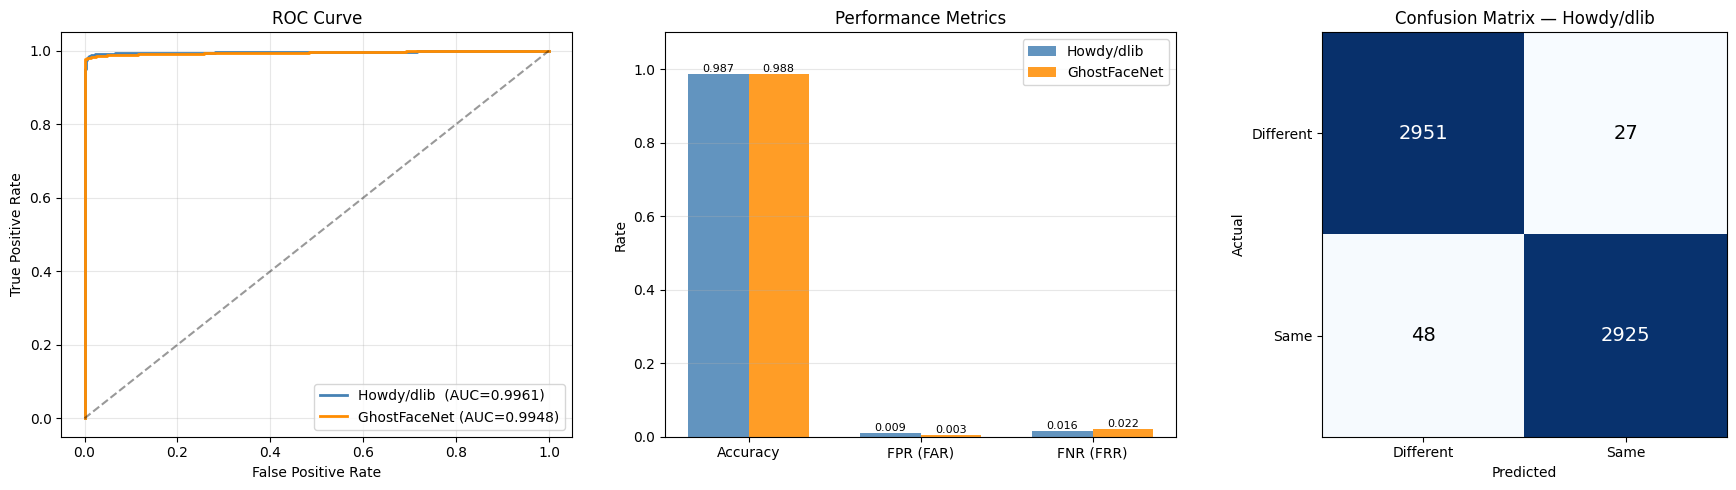


Howdy/dlib AUC:    0.9961
GhostFaceNet AUC:  0.9948


In [10]:
fpr_h, tpr_h, _ = roc_curve(eval_labels, howdy_scores)
fpr_g, tpr_g, _ = roc_curve(eval_labels, ghost_scores)
auc_h = auc(fpr_h, tpr_h)
auc_g = auc(fpr_g, tpr_g)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC curve ---
axes[0].plot(fpr_h, tpr_h, label=f"Howdy/dlib  (AUC={auc_h:.4f})", color="steelblue", lw=2)
axes[0].plot(fpr_g, tpr_g, label=f"GhostFaceNet (AUC={auc_g:.4f})", color="darkorange", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy / FPR / FNR bar chart ---
metric_keys = ["accuracy", "fpr", "fnr"]
metric_labels = ["Accuracy", "FPR (FAR)", "FNR (FRR)"]
x = np.arange(len(metric_labels))
w = 0.35
hv = [howdy_m[k] for k in metric_keys]
gv = [ghost_m[k] for k in metric_keys]
b1 = axes[1].bar(x - w / 2, hv, w, label="Howdy/dlib",   color="steelblue", alpha=0.85)
b2 = axes[1].bar(x + w / 2, gv, w, label="GhostFaceNet", color="darkorange", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Rate")
axes[1].set_title("Performance Metrics")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    axes[1].annotate(
        f"{bar.get_height():.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=8,
    )

# --- Confusion matrix side-by-side ---
for ax, m, name, color in [
    (axes[2], howdy_m, "Howdy/dlib", "Blues"),
]:
    cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    im = ax.imshow(cm, interpolation="nearest", cmap=color)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Different", "Same"])
    ax.set_yticklabels(["Different", "Same"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.tight_layout()
plt.savefig("face_recognition_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nHowdy/dlib AUC:    {auc_h:.4f}")
print(f"GhostFaceNet AUC:  {auc_g:.4f}")

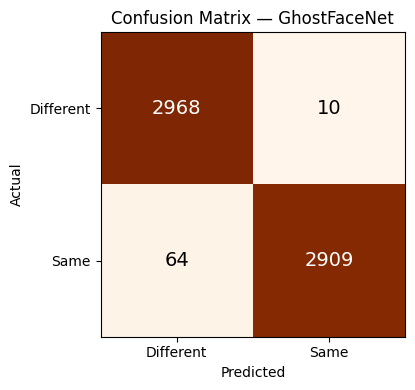

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.array([[ghost_m["tn"], ghost_m["fp"]], [ghost_m["fn"], ghost_m["tp"]]])
ax.imshow(cm, interpolation="nearest", cmap="Oranges")
ax.set_title("Confusion Matrix — GhostFaceNet")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Different", "Same"])
ax.set_yticklabels(["Different", "Same"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.tight_layout()
plt.show()